In [1]:
import pandas as pd 

df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

print(df.head())

   VIN (1-10)     County       City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King    Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish    Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King    Seattle    WA      98109.0        2019  TESLA   
3  5YJSA1E27G       King   Issaquah    WA      98027.0        2016  TESLA   
4  5YJYGDEE5M     Kitsap  Suquamish    WA      98392.0        2021  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   
3  MODEL S  Battery Electric Vehicle (BEV)   
4  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible             291   
1  Eligibility unknown as battery range has not b...               0   
2            Clean Alternative Fuel Vehicle 

Now, Lets clean the dataset before starting

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [3]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [4]:
df = df.dropna()

We checked null values and drop them for analysis

C:\Users\ulas_\AppData\Local\Temp\ipykernel_1164\1510207794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_adoption_by_year.index, y=ev_adoption_by_year.values,palette='viridis')


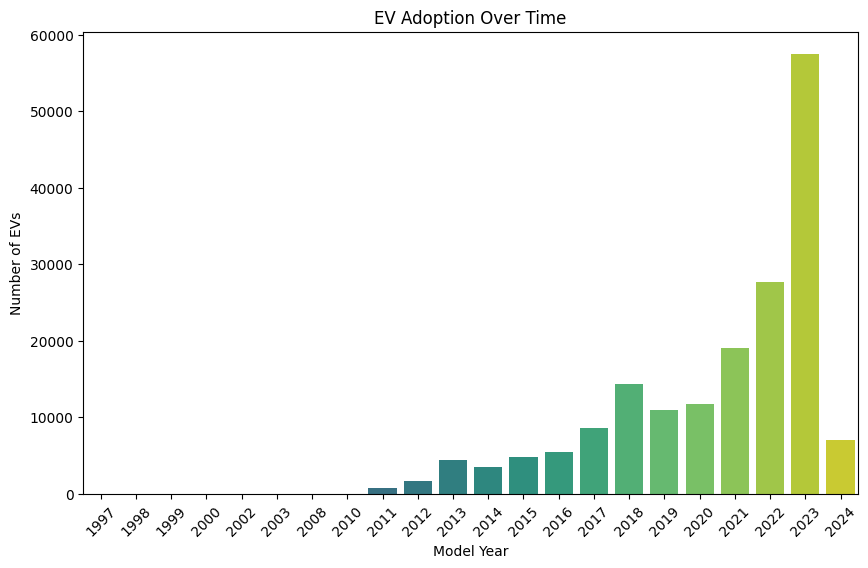

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ev_adoption_by_year = df['Model Year'].value_counts().sort_index()
sns.barplot(x=ev_adoption_by_year.index, y=ev_adoption_by_year.values,palette='viridis')
plt.title('EV Adoption Over Time')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')
plt.xticks(rotation=45)
plt.show()

This chart show us that EV adoption has been increasing over time,in 2016 there is a significant upward trend.The year 2023 shows a particularly sharp increase in the number of EVs

Now,Lets look top 3 counties based on EV registrations and analyses

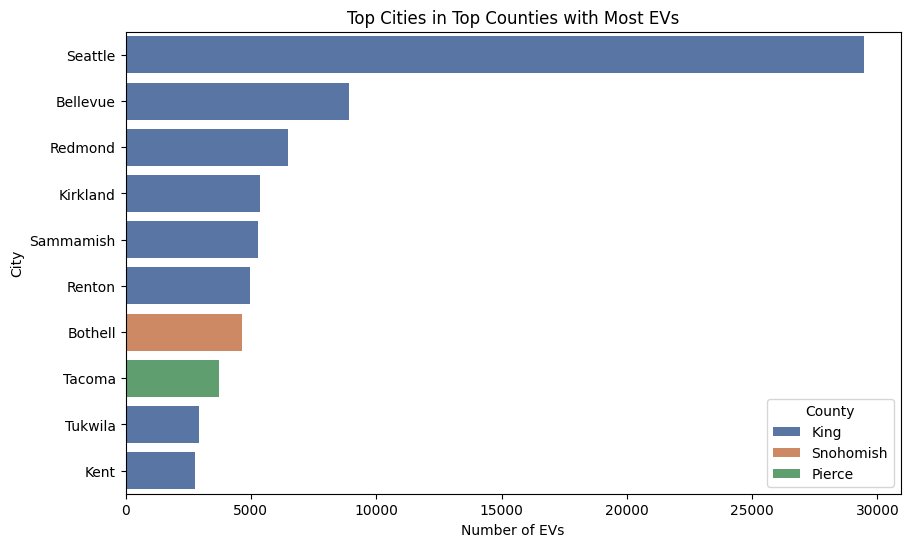

In [ ]:
ev_county_distribution = df['County'].value_counts()
top_counties = ev_county_distribution.head(3).index

top_counties_data = df[df['County'].isin(top_counties)]

ev_city_distribution_top_counties = top_counties_data.groupby(['County', 'City']).size().sort_values(ascending=False).reset_index(name='Number of EVs')

top_counties = ev_city_distribution_top_counties.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Number of EVs', y='City', hue='County', data=top_counties, palette="deep")
plt.title("Top Cities in Top Counties with Most EVs")
plt.xlabel("Number of EVs")
plt.ylabel("City")
plt.legend
plt.show()



The above graph compares the number of electric vehicles registered in various cities within three counties: King, Snohomish, and Pierce.Seattle, which is in King County, has the highest number of EV

Overall, the graph indicates that EV adoption is not uniform across the cities and is more concentrated in certain areas, particularly in King County.

Lets explore the types of electric vehicles represented in this dataset

C:\Users\ulas_\AppData\Local\Temp\ipykernel_1164\2528215805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_type_distribution.values, y=ev_type_distribution.index, palette='magma')


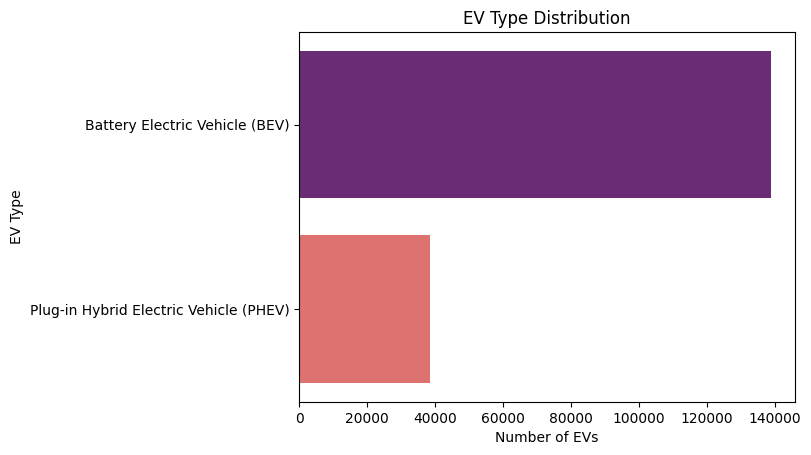

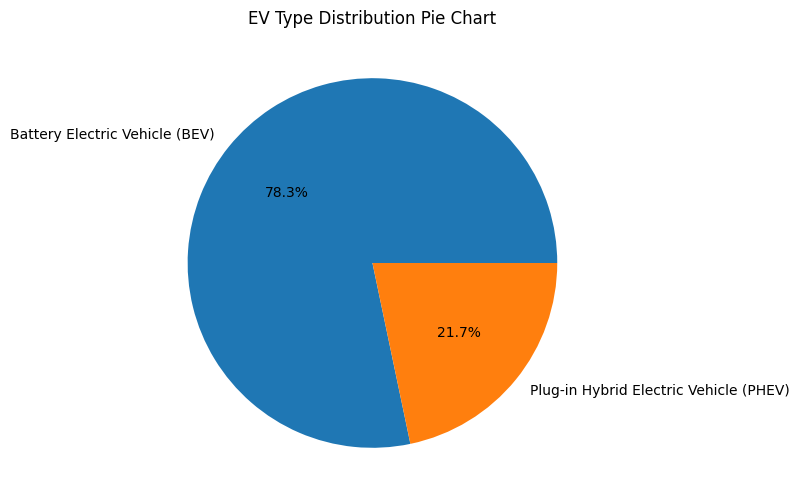

In [31]:
ev_type_distribution  = df['Electric Vehicle Type'].value_counts()

plt.Figure(figsize=(10, 6))
sns.barplot(x=ev_type_distribution.values, y=ev_type_distribution.index, palette='magma')
plt.title('EV Type Distribution')
plt.xlabel('Number of EVs')
plt.ylabel('EV Type')

plt.figure(figsize=(10, 6))
plt.pie(ev_type_distribution, labels=ev_type_distribution.index, autopct='%1.1f%%')
plt.title('EV Type Distribution Pie Chart')


plt.show()

The above graphs show that BEVs are more popular or preferred over PHEVs among the electric vehicles registered in the United States.

Let’s now focus on the popularity of electric vehicle manufacturers and models among the registered vehicles.

C:\Users\ulas_\AppData\Local\Temp\ipykernel_1164\19788641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_make_distribution.values, y=ev_make_distribution.index, palette='mako')


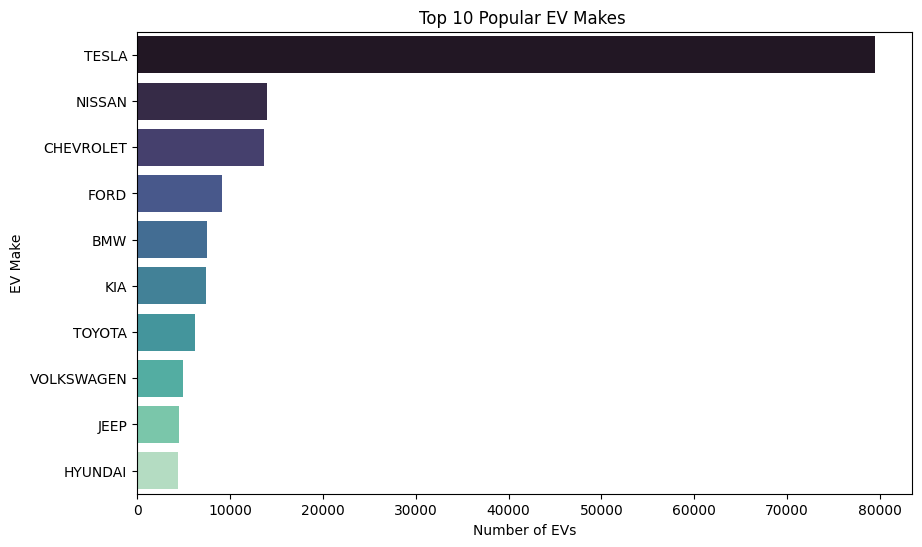

In [32]:
ev_make_distribution = df['Make'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=ev_make_distribution.values, y=ev_make_distribution.index, palette='mako')
plt.title('Top 10 Popular EV Makes ')
plt.xlabel('Number of EVs')
plt.ylabel('EV Make')
plt.show()


The above chart shows that TESLA leads by a substantial margin with highest number of vehicles

Lets check the most popular models within these top manufacturers

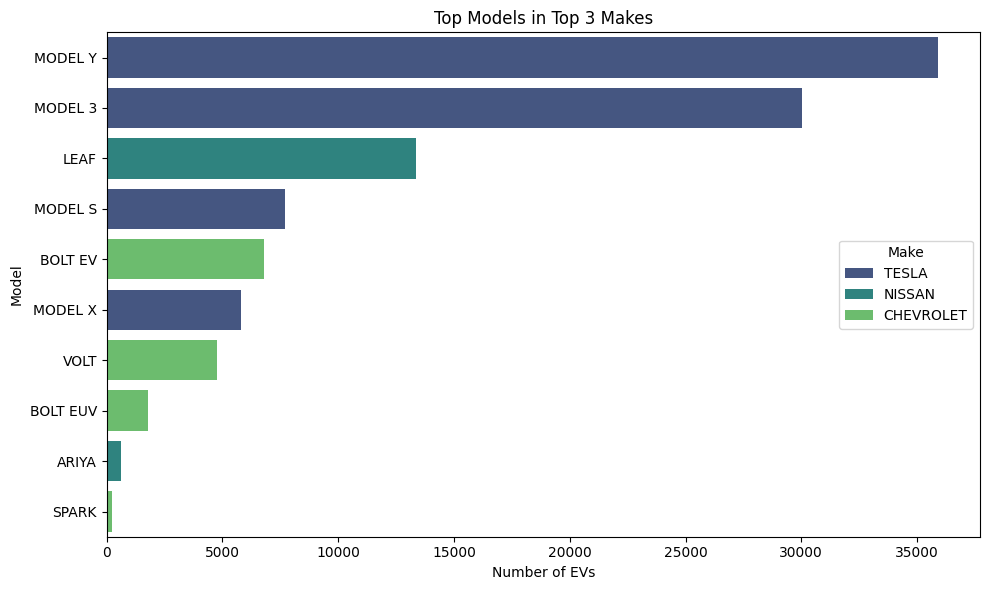

In [34]:
top_3_makes = ev_make_distribution.head(3).index

top_3_makes_data = df[df['Make'].isin(top_3_makes)]

ev_model_distribution_top_3_makes = top_3_makes_data.groupby(['Make', 'Model']).size().sort_values(ascending=False).reset_index(name='Number of EVs')

top_models = ev_model_distribution_top_3_makes.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Number of EVs', y='Model', hue='Make', data=top_models, palette="viridis")
plt.title("Top Models in Top 3 Makes")
plt.xlabel("Number of EVs")
plt.ylabel("Model")
plt.legend(title='Make', loc='center right')
plt.tight_layout()
plt.show()

The above chart shows TESLA's MODEL Y and MODEL 3 are the most registered vehicles and NISSAN's LEAF is the third most registered model

we will explore the electric range of vehicles, which is a critical factor for analyzing the market size of electric vehicles

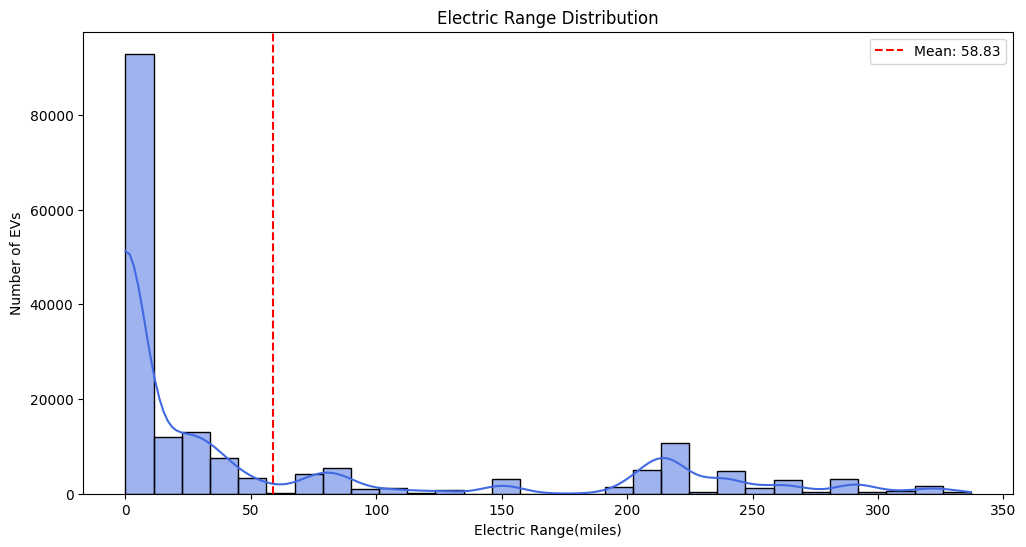

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Electric Range'], bins=30, kde=True, color='royalblue')
plt.title('Electric Range Distribution')
plt.xlabel('Electric Range(miles)')
plt.ylabel('Number of EVs')
plt.axvline(df['Electric Range'].mean(), color='red', linestyle='--', label=f'Mean: {df["Electric Range"].mean():.2f}')
plt.legend()
plt.show()

It suggests that while there are EVs available with high electric ranges, the average range is skewed lower due to a substantial number of vehicles with shorter ranges.

C:\Users\ulas_\AppData\Local\Temp\ipykernel_1164\1712194241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_range_by_make.values, y=avg_range_by_make.index, palette='viridis')


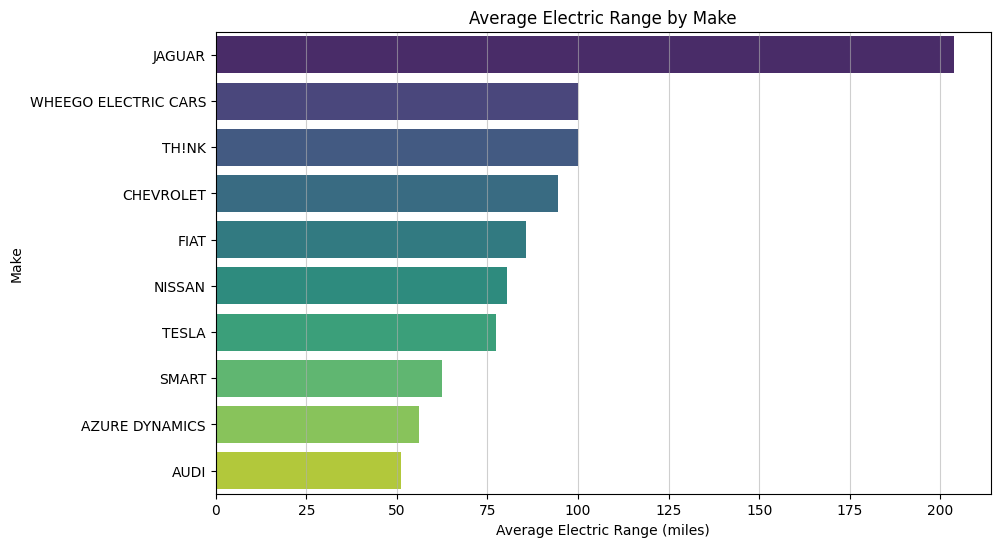

In [51]:
avg_range_by_make = df.groupby('Make')['Electric Range'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_range_by_make.values, y=avg_range_by_make.index, palette='viridis')
plt.title('Average Electric Range by Make')
plt.xlabel('Average Electric Range (miles)')
plt.ylabel('Make')
plt.grid(True,axis='x',alpha=0.6)
plt.show()

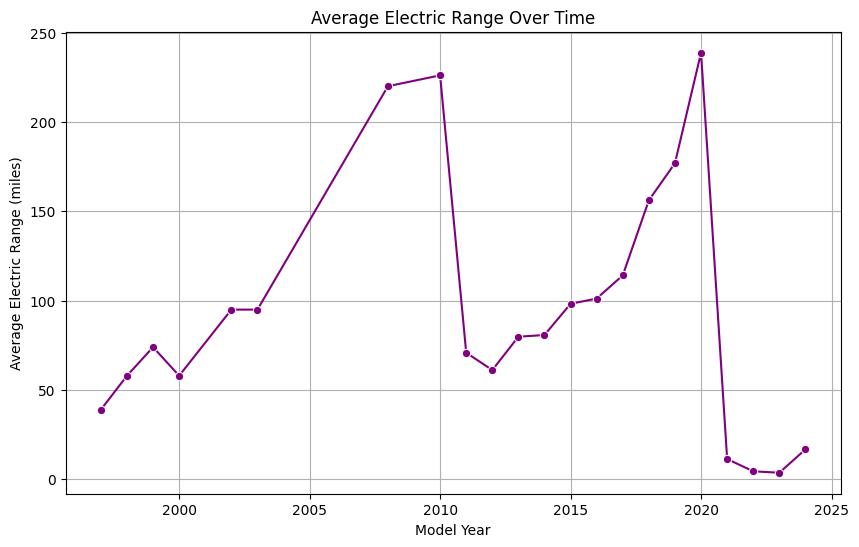

In [44]:
avg_range_by_year = df.groupby('Model Year')['Electric Range'].mean().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_range_by_year.index, y=avg_range_by_year.values, marker='o', color='purple')
plt.title('Average Electric Range Over Time')
plt.xlabel('Model Year')
plt.ylabel('Average Electric Range (miles)')
plt.grid(True)
plt.show()

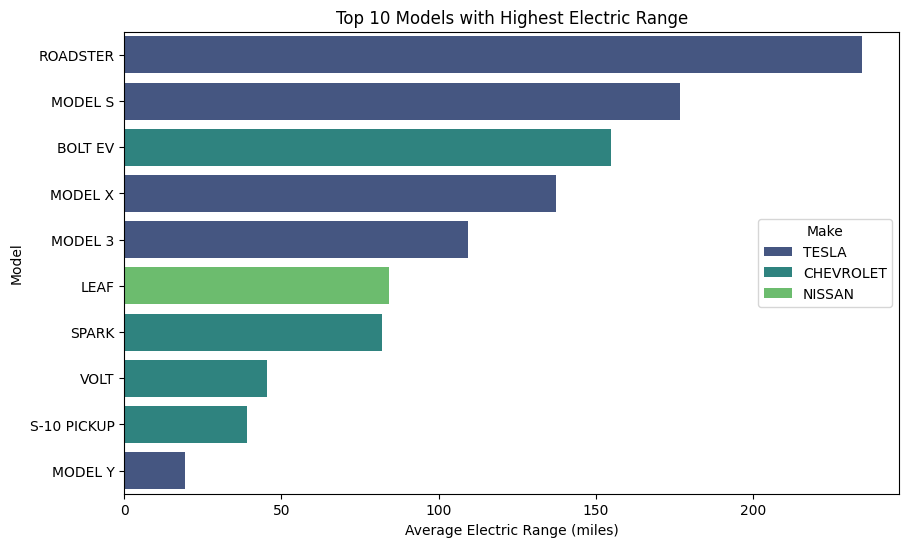

In [60]:
avg_range_by_model = top_3_makes_data.groupby(['Make','Model'])['Electric Range'].mean().sort_values(ascending=False).reset_index()

top_range_models = avg_range_by_model.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Electric Range', y='Model', hue='Make', data=top_range_models, palette='viridis')
plt.title('Top 10 Models with Highest Electric Range')
plt.xlabel('Average Electric Range (miles)')
plt.ylabel('Model')
plt.legend(title='Make', loc='center right') 
plt.show()

In [62]:
# calculate the number of EVs registered each year
ev_registration_counts = df['Model Year'].value_counts().sort_index()
ev_registration_counts

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       19
2010       23
2011      775
2012     1614
2013     4399
2014     3496
2015     4826
2016     5469
2017     8534
2018    14286
2019    10913
2020    11740
2021    19063
2022    27708
2023    57519
2024     7072
Name: count, dtype: int64

In [63]:
from scipy.optimize import curve_fit
import numpy as np

# filter the dataset to include years with complete data, assuming 2023 is the last complete year
filtered_years = ev_registration_counts[ev_registration_counts.index <= 2023]

# define a function for exponential growth to fit the data
def exp_growth(x, a, b):
    return a * np.exp(b * x)

# prepare the data for curve fitting
x_data = filtered_years.index - filtered_years.index.min()
y_data = filtered_years.values

# fit the data to the exponential growth function
params, covariance = curve_fit(exp_growth, x_data, y_data)

# use the fitted function to forecast the number of EVs for 2024 and the next five years
forecast_years = np.arange(2024, 2024 + 6) - filtered_years.index.min()
forecasted_values = exp_growth(forecast_years, *params)

# create a dictionary to display the forecasted values for easier interpretation
forecasted_evs = dict(zip(forecast_years + filtered_years.index.min(), forecasted_values))

print(forecasted_evs)

{np.int64(2024): np.float64(79079.20808938889), np.int64(2025): np.float64(119653.96274428742), np.int64(2026): np.float64(181047.22020265696), np.int64(2027): np.float64(273940.74706208805), np.int64(2028): np.float64(414497.01805382164), np.int64(2029): np.float64(627171.3128407666)}


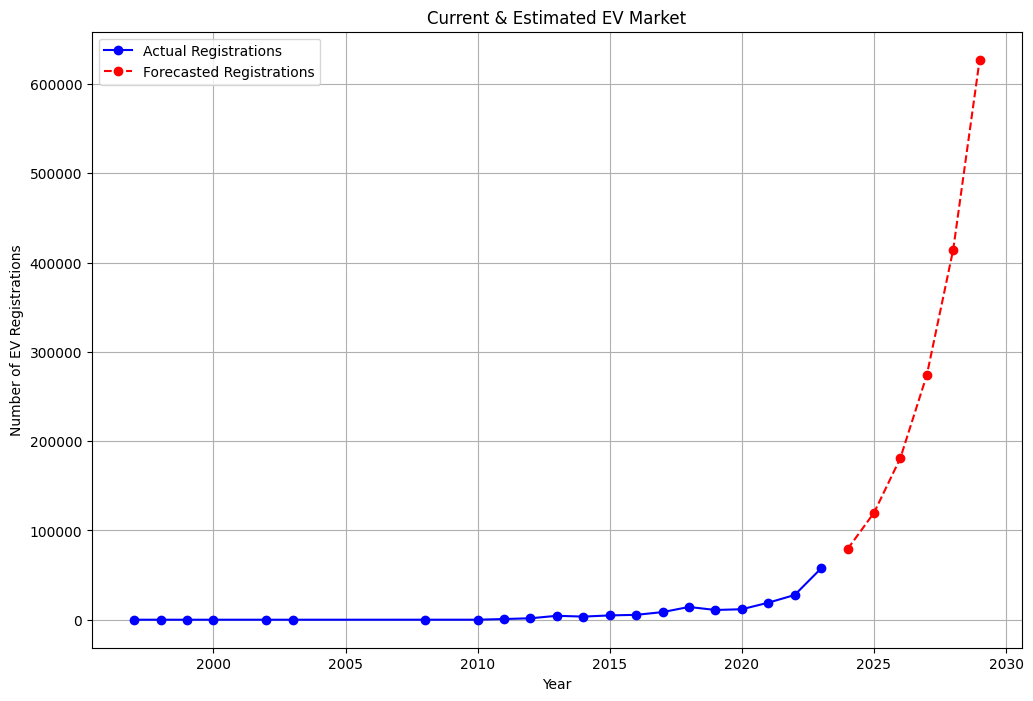

In [64]:
# prepare data for plotting
years = np.arange(filtered_years.index.min(), 2029 + 1)
actual_years = filtered_years.index
forecast_years_full = np.arange(2024, 2029 + 1)

# actual and forecasted values
actual_values = filtered_years.values
forecasted_values_full = [forecasted_evs[year] for year in forecast_years_full]

plt.figure(figsize=(12, 8))
plt.plot(actual_years, actual_values, 'bo-', label='Actual Registrations')
plt.plot(forecast_years_full, forecasted_values_full, 'ro--', label='Forecasted Registrations')

plt.title('Current & Estimated EV Market')
plt.xlabel('Year')
plt.ylabel('Number of EV Registrations')
plt.legend()
plt.grid(True)

plt.show()